## ***DATA ANALYSIS PYTHON PROJECT - 🎬 Netflix Analysis*** Designed & Developed by Shehzad Hussain



#### ***Import  libraries***



In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### ***Import  Raw Data***



In [2]:
df = pd.read_csv("Netflix's_data.csv", 
                 engine='python',
                 encoding_errors='ignore')

#### ***Sample Data***



In [3]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [4]:
df.tail()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
9832,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...
9833,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...
9834,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...
9835,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...
9836,1984-09-23,Threads,Documentary style account of a nuclear holocau...,13.354,186,7.8,en,"War, Drama, Science Fiction",https://image.tmdb.org/t/p/original/lBhU4U9Eeh...


#### ***Size of Data***


In [5]:
print("-" * 30)
print(f"SHAPE ANALYSIS")
print("-" * 30)
print(f"Total Rows: {df.shape[0]:,}") # Includes comma separators for large numbers
print(f"Total Columns:     {df.shape[1]}")
print("-" * 30)

------------------------------
SHAPE ANALYSIS
------------------------------
Total Rows: 9,837
Total Columns:     9
------------------------------


In [6]:
# df.columns insert
print("-" * 60)
print(f"{'#':<3} {'Column Name':<30} {'Data Type'}")
print("-" * 60)

for n, (col, dtype) in enumerate(df.dtypes.items(), 1):
    print(f"{n:<3} {col:<30} {dtype}")

print(f"\nTotal columns: {len(df.columns)}")
print("-" * 60)

------------------------------------------------------------
#   Column Name                    Data Type
------------------------------------------------------------
1   Release_Date                   str
2   Title                          str
3   Overview                       str
4   Popularity                     float64
5   Vote_Count                     str
6   Vote_Average                   str
7   Original_Language              str
8   Genre                          str
9   Poster_Url                     str

Total columns: 9
------------------------------------------------------------


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   str    
 1   Title              9828 non-null   str    
 2   Overview           9828 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   str    
 5   Vote_Average       9827 non-null   str    
 6   Original_Language  9827 non-null   str    
 7   Genre              9826 non-null   str    
 8   Poster_Url         9826 non-null   str    
dtypes: float64(1), str(8)
memory usage: 691.8 KB


***✅ Step 1 — Convert Data Types Correctly***

In [8]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')
df['Vote_Count'] = df['Vote_Count'].str.replace(',', '')
df['Vote_Count'] = pd.to_numeric(df['Vote_Count'], errors='coerce')
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')


***✅ Step 2 — Verify Changes***

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Release_Date       9827 non-null   datetime64[us]
 1   Title              9828 non-null   str           
 2   Overview           9828 non-null   str           
 3   Popularity         9827 non-null   float64       
 4   Vote_Count         9826 non-null   float64       
 5   Vote_Average       9826 non-null   float64       
 6   Original_Language  9827 non-null   str           
 7   Genre              9826 non-null   str           
 8   Poster_Url         9826 non-null   str           
dtypes: datetime64[us](1), float64(3), str(5)
memory usage: 691.8 KB


***✅ Step 3 — Check Missing Values***


In [10]:
def missing_values_report(df):
    # Calculate missing values and percentages
    missing_count = df.isnull().sum()
    missing_percentage = (df.isnull().sum() / len(df)) * 100
    
    # Combine into a table
    report = pd.concat([missing_count, missing_percentage], axis=1)
    report.columns = ['Missing Count', 'Percentage (%)']
    
    # Sort by highest missing values
    return report.sort_values(by='Missing Count', ascending=False)

# Usage
missing_values_report(df)

,Missing Count,Percentage (%)
Vote_Count,11,0.111823
Genre,11,0.111823
Poster_Url,11,0.111823
Vote_Average,11,0.111823
Release_Date,10,0.101657
Popularity,10,0.101657
Original_Language,10,0.101657
Title,9,0.091491
Overview,9,0.091491


In [11]:
# Drop rows where critical information is missing
df.dropna(subset=['Title', 'Release_Date', 'Genre'], inplace=True)

# Confirming the result
print(f"Remaining rows: {len(df)}")

Remaining rows: 9826


In [12]:
# Quick check for zeros
clean_report = df.isnull().sum().to_frame(name='Missing').query('Missing > 0')

if clean_report.empty:
    print("✅ Data is clean. No missing values remaining.")
else:
    print(clean_report)

✅ Data is clean. No missing values remaining.


In [13]:
# Only if you still have missing values in numbers
df['Vote_Average'] = df['Vote_Average'].fillna(df['Vote_Average'].median())
df['Popularity'] = df['Popularity'].fillna(df['Popularity'].median())

# For Categorical data like Genre or Language
df['Genre'] = df['Genre'].fillna('Unknown')

In [14]:

# Drop any row that failed the conversion (became NaN)
df.dropna(inplace=True)

print("Data cleaning complete. Ready for Analysis.")

Data cleaning complete. Ready for Analysis.


In [15]:
df.shape

(9826, 9)

***🎯 Key Observations***

In [16]:
df['Genre'] = df['Genre'].str.split(', ')
df_genre = df.explode('Genre')

In [17]:
df_genre['Genre'].value_counts().head(10)

Genre
Drama        3744
Comedy       3031
Action       2686
Thriller     2488
Adventure    1853
Romance      1476
Horror       1470
Animation    1438
Family       1414
Fantasy      1308
Name: count, dtype: int64

***📊 Professional Statistical Interpretation***

In [18]:
df.describe()

,Release_Date,Popularity,Vote_Count,Vote_Average
count,9826,9826.000000,9826.000000,9826.000000
mean,2006-09-23 04:47:14.276409,40.323951,1392.943721,6.439467
min,1902-04-17 00:00:00,13.354000,0.000000,0.000000
25%,2000-10-17 12:00:00,16.128250,146.000000,5.900000
50%,2011-09-12 00:00:00,21.195000,444.000000,6.500000
75%,2017-11-22 00:00:00,35.179250,1376.000000,7.100000
max,2024-07-03 00:00:00,5083.954000,31077.000000,10.000000
std,NaN,108.879332,2611.303856,1.129797


In [19]:
df_reliable = df[df['Vote_Count'] >= 100]

In [20]:
df[['Popularity', 'Vote_Count', 'Vote_Average']].skew()

Popularity      21.900501
Vote_Count       4.103409
Vote_Average    -2.085286
dtype: float64

In [21]:
df['Vote_Average'].value_counts().sort_index().head(10)

Vote_Average
0.0    100
1.5      1
1.8      1
2.0     18
2.2      1
2.4      1
2.5      2
2.6      1
2.8      2
2.9      2
Name: count, dtype: int64

In [22]:
df[df['Vote_Average'] == 0].shape

(100, 9)

In [23]:
df = df[df['Vote_Average'] > 0]

In [24]:
# Create a list of columns to check, excluding 'Genre'
cols_to_check = df.columns.difference(['Genre']).tolist()

# Now calculate duplicates based on those columns
duplicate_count = df.duplicated(subset=cols_to_check).sum()
duplicate_pct = (duplicate_count / len(df)) * 100

print(f"Duplicate Rows (excluding Genre list): {duplicate_count}")
print(f"Percentage: {duplicate_pct:.2f}%")

Duplicate Rows (excluding Genre list): 0
Percentage: 0.00%


In [25]:
df.columns

Index(['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count',
       'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url'],
      dtype='str')

***✅ Unnecessary columns removed.***

In [26]:
# List of columns that don't add value to numerical/trend analysis
cols_to_drop = ['Poster_Url', 'Overview','Original_Language']

# Drop columns
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print("✅ Unnecessary columns removed.")
print(f"Remaining columns: {df.columns.tolist()}")

✅ Unnecessary columns removed.
Remaining columns: ['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average', 'Genre']


##### 1. Extract Year

In [27]:
# 1. Convert to datetime first (errors='coerce' turns bad dates into NaT/Null)
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')

# 2. Now extract the year into a NEW column
df['Release_Date'] = df['Release_Date'].dt.year

# 3. Clean up: fill missing years and convert to integer
df['Release_Date'] = df['Release_Date'].fillna(0).astype(int)

# Check the results
print(df[['Release_Date']].sort_values(by='Release_Date' , ascending=False).head(10))

      Release_Date
4223          2022
4320          2022
4333          2022
1             2022
2             2022
120           2022
121           2022
5             2022
6             2022
12            2022


In [28]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,8.3,"[Action, Adventure, Science Fiction]"
1,2022,The Batman,3827.658,1151.0,8.1,"[Crime, Mystery, Thriller]"
2,2022,No Exit,2618.087,122.0,6.3,[Thriller]
3,2021,Encanto,2402.201,5076.0,7.7,"[Animation, Comedy, Family, Fantasy]"
4,2021,The King's Man,1895.511,1793.0,7.0,"[Action, Adventure, Thriller, War]"


***Define Rating Bands***

In [29]:
# Define bins and labels
bins = [0, 4, 6, 7.5, 8.5, 10]
labels = ['Bad ', 
          'Poor ', 
          'Average ', 
          'Good ', 
          'Excellent ']

# Create new column
df['Vote_Average'] = pd.cut(df['Vote_Average'], 
                                bins=bins, 
                                labels=labels,
                                include_lowest=True)

##### Check Distribution

In [30]:
df['Vote_Average'].value_counts().sort_index()

Vote_Average
Bad            105
Poor          2705
Average       5760
Good          1126
Excellent       30
Name: count, dtype: int64

In [31]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,Good,"[Action, Adventure, Science Fiction]"
1,2022,The Batman,3827.658,1151.0,Good,"[Crime, Mystery, Thriller]"
2,2022,No Exit,2618.087,122.0,Average,[Thriller]
3,2021,Encanto,2402.201,5076.0,Good,"[Animation, Comedy, Family, Fantasy]"
4,2021,The King's Man,1895.511,1793.0,Average,"[Action, Adventure, Thriller, War]"


In [32]:
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='str')

***Check null values***

In [33]:
# 1. Store count before dropping
before_count = len(df)

# 2. Drop rows where essential columns are null
# We include 'Title', 'Release_Date', and 'Vote_Average' as mandatory fields
df.dropna(subset=['Title', 'Release_Date', 'Vote_Average'], inplace=True)

# 3. Optional: Fill minor missing values in other columns
# If Genre is missing, we label it 'Unknown' rather than deleting the movie
if 'Genre' in df.columns:
    df['Genre'] = df['Genre'].fillna('Unknown')

# 4. Reset the index (Crucial step after dropping rows)
df.reset_index(drop=True, inplace=True)

# 5. Final Report
after_count = len(df)
removed = before_count - after_count

print(f"{'='*40}")
print(f"🧹 NULL VALUE REMOVAL REPORT")
print(f"{'='*40}")
print(f"Rows before cleaning: {before_count}")
print(f"Rows removed:        {removed}")
print(f"Rows remaining:      {after_count}")
print(f"{'='*40}")

🧹 NULL VALUE REMOVAL REPORT
Rows before cleaning: 9726
Rows removed:        0
Rows remaining:      9726


##### Genre datatype changed 

In [34]:
# 1. Convert the list/object to a string
df['Genre'] = df['Genre'].astype(str)

# 2. Convert to category
df['Genre'] = df['Genre'].astype('category')

print(f"✅ Genre type changed to: {df['Genre'].dtype}")

✅ Genre type changed to: category


In [35]:
df.nunique()

Release_Date     100
Title           9414
Popularity      8087
Vote_Count      3265
Vote_Average       5
Genre           2324
dtype: int64

In [36]:
# 1. Force the column to be a plain string and remove brackets/quotes
# This cleans "['Action', 'Drama']" into "Action, Drama"
df['Genre'] = (df['Genre'].astype(str)
               .str.replace("[", "", regex=False)
               .str.replace("]", "", regex=False)
               .str.replace("'", "", regex=False)
               .str.replace('"', "", regex=False))

# 2. Split the string into a real Python list
df['Genre'] = df['Genre'].str.split(',')

# 3. Explode the lists into individual rows
df_genres = df.explode('Genre')

# 4. Final Cleanup: Remove extra spaces and convert to category
df_genres['Genre'] = df_genres['Genre'].str.strip().astype('category')

# 5. Drop any empty strings that might have been created
df_genres = df_genres[df_genres['Genre'] != ""]

print("✅ Success! Genres are now split and categorized.")
print(f"Total rows in analysis: {len(df_genres)}")
print("\nTop 5 Genres:")
print(df_genres['Genre'].value_counts().head())

✅ Success! Genres are now split and categorized.
Total rows in analysis: 25551

Top 5 Genres:
Genre
Drama        3715
Comedy       3006
Action       2652
Thriller     2473
Adventure    1829
Name: count, dtype: int64


In [37]:
# ============================================
# STEP 1: Break category lock
# ============================================
df['Genre'] = [str(x) for x in df['Genre']]

# ============================================
# STEP 2: Clean brackets and quotes
# ============================================
df['Genre'] = (df['Genre']
               .str.replace(r"[\[\]']", "", regex=True)
               .str.replace('"', ""))

# ============================================
# STEP 3: Split into list
# ============================================
df['Genre'] = df['Genre'].str.split(',')

# ============================================
# STEP 4: Explode on same df
# ============================================
df = df.explode('Genre')

# ============================================
# STEP 5: Clean each genre value
# ============================================
df['Genre'] = df['Genre'].str.strip()

# ============================================
# STEP 6: Remove empty/null genres
# ============================================
df = df[df['Genre'].notna()]
df = df[df['Genre'] != ""]
df = df[df['Genre'] != "nan"]

# ============================================
# STEP 7: Convert to category
# ============================================
df['Genre'] = df['Genre'].astype('category')

# ============================================
# STEP 8: Reset index
# ============================================
df.reset_index(drop=True, inplace=True)

# ============================================
# FINAL VERIFICATION
# ============================================
print(f"{'='*45}")
print(f"📋  GENRE SPLIT REPORT")
print(f"{'='*45}")
print(f"  Final Shape     :  {df.shape}")
print(f"  Unique Genres   :  {df['Genre'].nunique()}")
print(f"{'='*45}")

print(f"\n🎬 Sample:")
print(df[['Title', 'Genre']].head(10))

print(f"\n📊 Genre Distribution:")
print(df['Genre'].value_counts())

📋  GENRE SPLIT REPORT
  Final Shape     :  (25551, 6)
  Unique Genres   :  19

🎬 Sample:
                     Title            Genre
0  Spider-Man: No Way Home           Action
1  Spider-Man: No Way Home        Adventure
2  Spider-Man: No Way Home  Science Fiction
3               The Batman            Crime
4               The Batman          Mystery
5               The Batman         Thriller
6                  No Exit         Thriller
7                  Encanto        Animation
8                  Encanto           Comedy
9                  Encanto           Family

📊 Genre Distribution:
Genre
Drama              3715
Comedy             3006
Action             2652
Thriller           2473
Adventure          1829
Romance            1461
Horror             1457
Animation          1425
Family             1405
Fantasy            1295
Science Fiction    1255
Crime              1235
Mystery             765
History             426
War                 307
Music               291
TV Movie      

In [41]:
# Count each genre
genre_counts = df['Genre'].value_counts().reset_index()
genre_counts.columns = ['Genre', 'Movie_Count']

# Add percentage
genre_counts['Percentage'] = (
    genre_counts['Movie_Count'] / 
    genre_counts['Movie_Count'].sum() * 100
).round(2)

print(f"{'='*45}")
print(f"📊  GENRE FREQUENCY REPORT")
print(f"{'='*45}")
print(genre_counts)
print(f"{'='*45}")
print(f"\n🏆 Most Frequent Genre: {genre_counts['Genre'].iloc[0]}")
print(f"   Movie Count        : {genre_counts['Movie_Count'].iloc[0]}")
print(f"   Percentage         : {genre_counts['Percentage'].iloc[0]}%")

📊  GENRE FREQUENCY REPORT
              Genre  Movie_Count  Percentage
0             Drama         3715       14.54
1            Comedy         3006       11.76
2            Action         2652       10.38
3          Thriller         2473        9.68
4         Adventure         1829        7.16
5           Romance         1461        5.72
6            Horror         1457        5.70
7         Animation         1425        5.58
8            Family         1405        5.50
9           Fantasy         1295        5.07
10  Science Fiction         1255        4.91
11            Crime         1235        4.83
12          Mystery          765        2.99
13          History          426        1.67
14              War          307        1.20
15            Music          291        1.14
16         TV Movie          214        0.84
17      Documentary          203        0.79
18          Western          137        0.54

🏆 Most Frequent Genre: Drama
   Movie Count        : 3715
   Percentage  

#### ***Data Visulization***


##### What is the most frequent genre of movies released on Netflix?

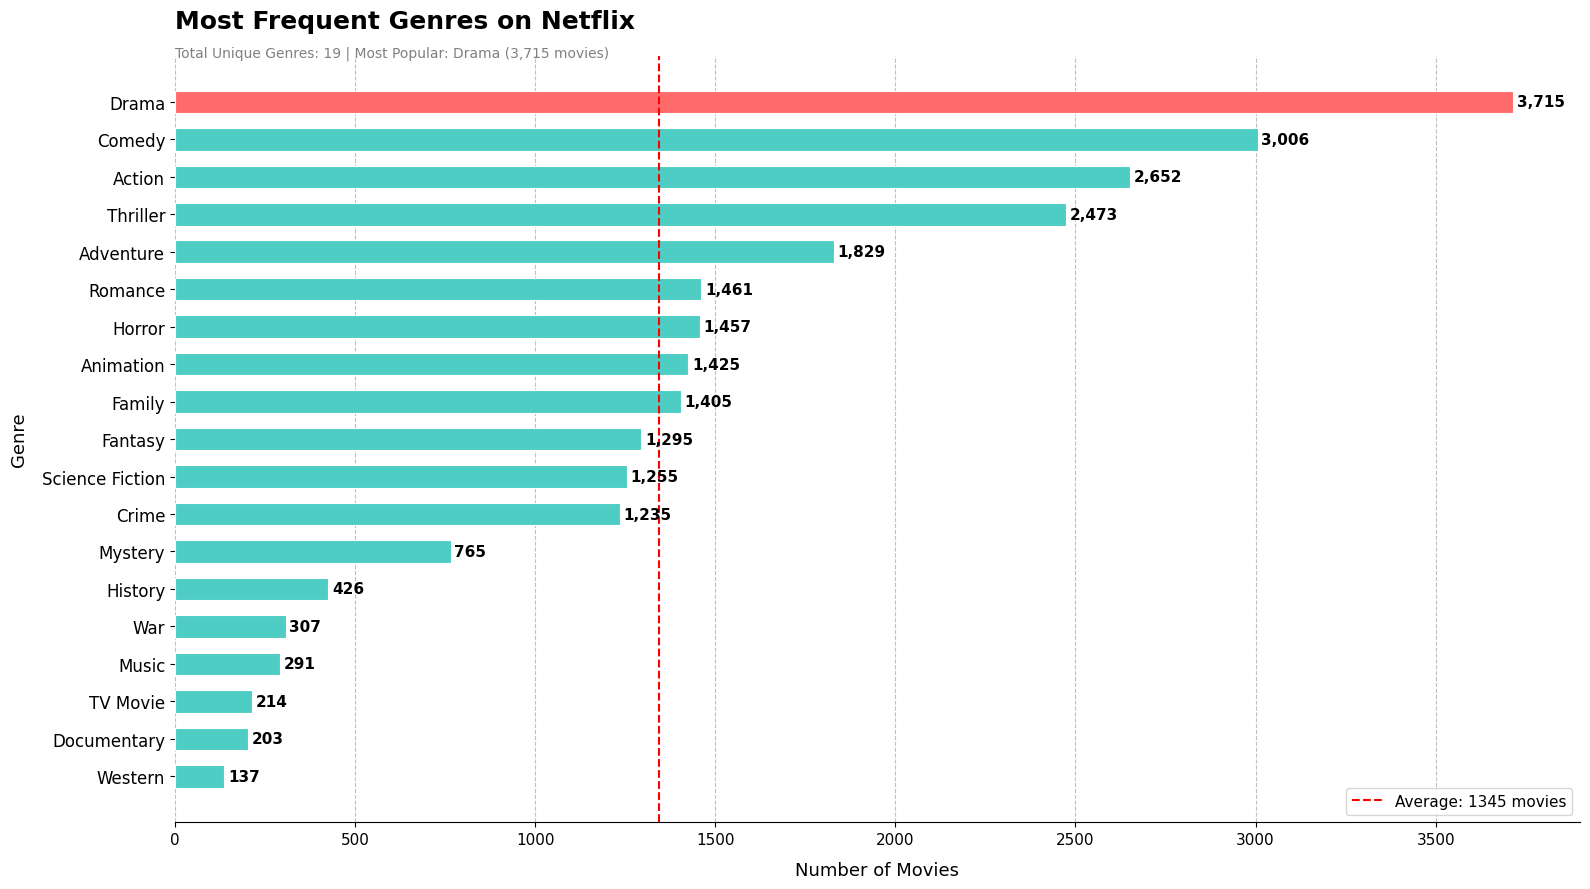

GENRE FREQUENCY REPORT
Rank   Genre                     Count      %
1      Drama                     3715       14.54%
2      Comedy                    3006       11.76%
3      Action                    2652       10.38%
4      Thriller                  2473       9.68%
5      Adventure                 1829       7.16%
6      Romance                   1461       5.72%
7      Horror                    1457       5.70%
8      Animation                 1425       5.58%
9      Family                    1405       5.50%
10     Fantasy                   1295       5.07%
11     Science Fiction           1255       4.91%
12     Crime                     1235       4.83%
13     Mystery                   765        2.99%
14     History                   426        1.67%
15     War                       307        1.20%
16     Music                     291        1.14%
17     TV Movie                  214        0.84%
18     Documentary               203        0.79%
19     Western              

In [ ]:

# ============================================
# STEP 1: Prepare Data
# ============================================
genre_counts = (df['Genre']
                .value_counts()
                .reset_index())
genre_counts.columns = ['Genre', 'Movie_Count']

# ============================================
# STEP 2: Plot Setup
# ============================================
fig, ax = plt.subplots(figsize=(16, 9))

# Define colors (first bar highlighted in red)
colors = ['#FF6B6B'] + ['#4ECDC4'] * (len(genre_counts) - 1)

# ============================================
# STEP 3: Draw Horizontal Bar Chart
#         (Much cleaner for many categories)
# ============================================
bars = ax.barh(
    y=genre_counts['Genre'],
    width=genre_counts['Movie_Count'],
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    height=0.6
)

# ============================================
# STEP 4: Add Count Labels Inside Each Bar
# ============================================
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 10,
        bar.get_y() + bar.get_height() / 2,
        f'{int(width):,}',
        va='center',
        ha='left',
        fontsize=11,
        fontweight='bold',
        color='black'
    )

# ============================================
# STEP 5: Sort Bars (Largest on Top)
# ============================================
ax.invert_yaxis()

# ============================================
# STEP 6: Styling
# ============================================
ax.set_title(
    'Most Frequent Genres on Netflix',
    fontsize=18,
    fontweight='bold',
    pad=20,
    loc='left'
)

ax.set_xlabel(
    'Number of Movies',
    fontsize=13,
    labelpad=10
)

ax.set_ylabel(
    'Genre',
    fontsize=13,
    labelpad=10
)

# Add gridlines
ax.xaxis.grid(True, linestyle='--', alpha=0.5, color='gray')
ax.set_axisbelow(True)

# Add average line
avg = genre_counts['Movie_Count'].mean()
ax.axvline(
    x=avg,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Average: {avg:.0f} movies'
)

# Add subtitle annotation
ax.text(
    0, -1.2,
    f'Total Unique Genres: {len(genre_counts)} | '
    f'Most Popular: {genre_counts["Genre"].iloc[0]} '
    f'({genre_counts["Movie_Count"].iloc[0]:,} movies)',
    fontsize=10,
    color='gray',
    transform=ax.transData
)

# Remove borders
sns.despine(left=True, bottom=False)

# Tick size
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=11)

ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

# ============================================
# STEP 7: Print Insight
# ============================================
print(f"{'='*50}")
print(f"GENRE FREQUENCY REPORT")
print(f"{'='*50}")
print(f"{'Rank':<6} {'Genre':<25} {'Count':<10} {'%'}")
print(f"{'='*50}")
for i, row in genre_counts.iterrows():
    pct = row['Movie_Count'] / genre_counts['Movie_Count'].sum() * 100
    print(f"{i+1:<6} {row['Genre']:<25} "
          f"{row['Movie_Count']:<10} {pct:.2f}%")
print(f"{'='*50}")

****Which has highest votes in vote avg column?****

In [52]:
# ============================================
# Vote Average Distribution
# ============================================
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y='Content_Category',
    order=df['Vote_Average'].value_counts().index,
    color='#4287f5',
    edgecolor='black'
)

plt.title('Vote Average Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Number of Movies', fontsize=12)
plt.ylabel('Rating Category',  fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `Content_Category` for `y`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>